In [1]:
# Cell 1: Imports and Configuration
import numpy as np
import pandas as pd
from scipy.stats import poisson
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', None)
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Cell 2: Fetch and Clean Match Data
url_2425 = "https://www.football-data.co.uk/mmz4281/2425/E0.csv"

# Load match records
df_raw = pd.read_csv(url_2425)

# Filter down to essential match modeling columns:
# FTHG = Full Time Home Goals, FTAG = Full Time Away Goals, FTR = Full Time Result
matches = df_raw[['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR']].dropna()

# Rename for clarity
matches = matches.rename(columns={
    'HomeTeam': 'home_team',
    'AwayTeam': 'away_team',
    'FTHG': 'home_goals',
    'FTAG': 'away_goals',
    'FTR': 'result'
})

print(f"Total Matches Loaded: {len(matches)}")
matches.head(10)

Total Matches Loaded: 380


,Date,home_team,away_team,home_goals,away_goals,result
0,16/08/2024,Man United,Fulham,1,0,H
1,17/08/2024,Ipswich,Liverpool,0,2,A
2,17/08/2024,Arsenal,Wolves,2,0,H
3,17/08/2024,Everton,Brighton,0,3,A
4,17/08/2024,Newcastle,Southampton,1,0,H
5,17/08/2024,Nott'm Forest,Bournemouth,1,1,D
6,17/08/2024,West Ham,Aston Villa,1,2,A
7,18/08/2024,Brentford,Crystal Palace,2,1,H
8,18/08/2024,Chelsea,Man City,0,2,A
9,19/08/2024,Leicester,Tottenham,1,1,D


In [3]:
# Cell 3: Compute Relative Attack & Defense Ratings

# 1. League-wide averages per match
avg_home_goals = matches['home_goals'].mean()
avg_away_goals = matches['away_goals'].mean()

print(f"League Avg Home Goals: {avg_home_goals:.3f}")
print(f"League Avg Away Goals: {avg_away_goals:.3f}")

# 2. Team-level home performance
home_stats = matches.groupby('home_team').agg(
    home_games=('home_goals', 'count'),
    home_goals_scored=('home_goals', 'sum'),
    home_goals_conceded=('away_goals', 'sum')
)

# 3. Team-level away performance
away_stats = matches.groupby('away_team').agg(
    away_games=('away_goals', 'count'),
    away_goals_scored=('away_goals', 'sum'),
    away_goals_conceded=('home_goals', 'sum')
)

# 4. Merge into a master team ratings table
team_ratings = home_stats.merge(away_stats, left_index=True, right_index=True)

# Calculate normalized Attack and Defense metrics
team_ratings['home_attack'] = (team_ratings['home_goals_scored'] / team_ratings['home_games']) / avg_home_goals
team_ratings['home_defense'] = (team_ratings['home_goals_conceded'] / team_ratings['home_games']) / avg_away_goals

team_ratings['away_attack'] = (team_ratings['away_goals_scored'] / team_ratings['away_games']) / avg_away_goals
team_ratings['away_defense'] = (team_ratings['away_goals_conceded'] / team_ratings['away_games']) / avg_home_goals

# Overall normalized metrics
team_ratings['overall_attack'] = (team_ratings['home_attack'] + team_ratings['away_attack']) / 2
team_ratings['overall_defense'] = (team_ratings['home_defense'] + team_ratings['away_defense']) / 2

team_ratings = team_ratings.sort_values(by='overall_attack', ascending=False)
team_ratings[['overall_attack', 'overall_defense']].head(10)

League Avg Home Goals: 1.513
League Avg Away Goals: 1.421


,overall_attack,overall_defense
home_team,,
Liverpool,1.545250,0.731079
Man City,1.284863,0.791143
Arsenal,1.238325,0.610467
Newcastle,1.214171,0.839936
Brighton,1.188406,1.055395
Brentford,1.177134,1.030757
Chelsea,1.145733,0.768116
Tottenham,1.145733,1.169887
Bournemouth,1.048148,0.818035


In [4]:
# Cell 4: Single Fixture Simulator Function
def simulate_match(home_team, away_team, ratings, avg_home_g, avg_away_g):
    """
    Simulates a match between two clubs using Poisson goal expectation.
    Returns: (home_goals, away_goals)
    """
    h_att = ratings.loc[home_team, 'home_attack']
    h_def = ratings.loc[home_team, 'home_defense']
    a_att = ratings.loc[away_team, 'away_attack']
    a_def = ratings.loc[away_team, 'away_defense']
    
    # Calculate Expected Goals (xG)
    lambda_home = h_att * a_def * avg_home_g
    mu_away = a_att * h_def * avg_away_g
    
    # Generate random goal outcomes from Poisson distribution
    sim_home_goals = np.random.poisson(lambda_home)
    sim_away_goals = np.random.poisson(mu_away)
    
    return sim_home_goals, sim_away_goals

# Quick test: Chelsea vs Arsenal
test_h, test_a = simulate_match('Chelsea', 'Arsenal', team_ratings, avg_home_goals, avg_away_goals)
print(f"Simulated Test Result: Chelsea {test_h} - {test_a} Arsenal")

Simulated Test Result: Chelsea 1 - 2 Arsenal


In [5]:
# Cell 5: Advanced Team Profiler (Depth, Discipline, & Tactical Profile)

# 1. Define squad attributes based on historical metrics
# - squad_depth: 1.0 (world-class bench) to 0.5 (heavy reliance on starting XI)
# - discipline_risk: probability of cards/suspension issues per match
# - giant_killer_factor: boost multiplier against top-tier possession teams
team_profiles = {
    'Arsenal':         {'squad_depth': 0.90, 'discipline_risk': 0.08, 'is_top_tier': True,  'giant_killer': 1.00},
    'Aston Villa':     {'squad_depth': 0.80, 'discipline_risk': 0.10, 'is_top_tier': False, 'giant_killer': 1.12},
    'Bournemouth':     {'squad_depth': 0.70, 'discipline_risk': 0.11, 'is_top_tier': False, 'giant_killer': 1.15},
    'Brentford':       {'squad_depth': 0.72, 'discipline_risk': 0.09, 'is_top_tier': False, 'giant_killer': 1.18}, # Elite set-pieces & direct transition
    'Brighton':        {'squad_depth': 0.78, 'discipline_risk': 0.09, 'is_top_tier': False, 'giant_killer': 1.16}, # High press & tactical build-up
    'Chelsea':         {'squad_depth': 0.92, 'discipline_risk': 0.12, 'is_top_tier': True,  'giant_killer': 1.00}, # Deep bench, high card volatility
    'Crystal Palace':  {'squad_depth': 0.68, 'discipline_risk': 0.10, 'is_top_tier': False, 'giant_killer': 1.08},
    'Everton':         {'squad_depth': 0.65, 'discipline_risk': 0.12, 'is_top_tier': False, 'giant_killer': 1.06},
    'Fulham':          {'squad_depth': 0.70, 'discipline_risk': 0.10, 'is_top_tier': False, 'giant_killer': 1.05},
    'Ipswich':         {'squad_depth': 0.58, 'discipline_risk': 0.12, 'is_top_tier': False, 'giant_killer': 1.02},
    'Leicester':       {'squad_depth': 0.62, 'discipline_risk': 0.11, 'is_top_tier': False, 'giant_killer': 1.04},
    'Liverpool':       {'squad_depth': 0.90, 'discipline_risk': 0.07, 'is_top_tier': True,  'giant_killer': 1.00},
    'Man City':        {'squad_depth': 0.96, 'discipline_risk': 0.06, 'is_top_tier': True,  'giant_killer': 1.00},
    'Man United':      {'squad_depth': 0.82, 'discipline_risk': 0.11, 'is_top_tier': True,  'giant_killer': 1.00},
    'Newcastle':       {'squad_depth': 0.80, 'discipline_risk': 0.12, 'is_top_tier': False, 'giant_killer': 1.14},
    'Nott\'m Forest':  {'squad_depth': 0.68, 'discipline_risk': 0.13, 'is_top_tier': False, 'giant_killer': 1.08},
    'Southampton':     {'squad_depth': 0.60, 'discipline_risk': 0.11, 'is_top_tier': False, 'giant_killer': 1.02},
    'Tottenham':       {'squad_depth': 0.82, 'discipline_risk': 0.11, 'is_top_tier': True,  'giant_killer': 1.00},
    'West Ham':        {'squad_depth': 0.72, 'discipline_risk': 0.10, 'is_top_tier': False, 'giant_killer': 1.07},
    'Wolves':          {'squad_depth': 0.66, 'discipline_risk': 0.12, 'is_top_tier': False, 'giant_killer': 1.06}
}

df_profiles = pd.DataFrame.from_dict(team_profiles, orient='index')
df_profiles.head(20)

,squad_depth,discipline_risk,is_top_tier,giant_killer
Arsenal,0.90,0.08,True,1.00
Aston Villa,0.80,0.10,False,1.12
Bournemouth,0.70,0.11,False,1.15
Brentford,0.72,0.09,False,1.18
Brighton,0.78,0.09,False,1.16
Chelsea,0.92,0.12,True,1.00
Crystal Palace,0.68,0.10,False,1.08
Everton,0.65,0.12,False,1.06
Fulham,0.70,0.10,False,1.05
Ipswich,0.58,0.12,False,1.02


In [6]:
# Cell 6: Realistic Match Engine with Real-World Shocks

def simulate_realistic_match(home_team, away_team, ratings, profiles, avg_home_g, avg_away_g):
    """
    Simulates a match factoring in:
    - Base Poisson ratings
    - Squad Depth / Injury Shock
    - Red cards / Disciplinary penalties
    - Tactical 'Giant Killer' counter-attacking boosts
    """
    # 1. Base attack & defense ratings
    h_att = ratings.loc[home_team, 'home_attack']
    h_def = ratings.loc[home_team, 'home_defense']
    a_att = ratings.loc[away_team, 'away_attack']
    a_def = ratings.loc[away_team, 'away_defense']
    
    # 2. Get club profiles
    h_prof = profiles.loc[home_team] if home_team in profiles.index else {'squad_depth': 0.7, 'discipline_risk': 0.1, 'is_top_tier': False, 'giant_killer': 1.0}
    a_prof = profiles.loc[away_team] if away_team in profiles.index else {'squad_depth': 0.7, 'discipline_risk': 0.1, 'is_top_tier': False, 'giant_killer': 1.0}

    # 3. Factor 1: Injury Shock (15% chance a key player is missing this week)
    if np.random.rand() < 0.15:
        # Depth penalty: deep teams (0.95) lose almost nothing; thin teams (0.60) suffer
        h_att *= (1.0 - 0.20 * (1.0 - h_prof['squad_depth']))
        h_def *= (1.0 + 0.15 * (1.0 - h_prof['squad_depth']))
        
    if np.random.rand() < 0.15:
        a_att *= (1.0 - 0.20 * (1.0 - a_prof['squad_depth']))
        a_def *= (1.0 + 0.15 * (1.0 - a_prof['squad_depth']))

    # 4. Factor 2: Disciplinary Shock / Red Card in Match
    # Home red card / suspension shock:
    if np.random.rand() < h_prof['discipline_risk']:
        h_att *= 0.75   # Attack drops significantly
        h_def *= 1.40   # Concedes far more chances
        
    # Away red card / suspension shock:
    if np.random.rand() < a_prof['discipline_risk']:
        a_att *= 0.75
        a_def *= 1.40

    # 5. Factor 3: 'Giant Killer' Tactical Boost
    # If underdog plays a top tier club, apply counter-attack multiplier
    if (not h_prof['is_top_tier']) and a_prof['is_top_tier']:
        h_att *= h_prof['giant_killer']
        
    if (not a_prof['is_top_tier']) and h_prof['is_top_tier']:
        a_att *= a_prof['giant_killer']

    # 6. Compute Final Expected Goals (xG)
    lambda_home = max(0.1, h_att * a_def * avg_home_g)
    mu_away = max(0.1, a_att * h_def * avg_away_g)

    # 7. Draw Goals from Poisson Distribution
    sim_home_goals = np.random.poisson(lambda_home)
    sim_away_goals = np.random.poisson(mu_away)

    return sim_home_goals, sim_away_goals

In [7]:
# Cell 7: 1,000-Match Simulation Test (Brentford vs Man City)
brentford_wins = 0
draws = 0
city_wins = 0

for _ in range(1000):
    b_goals, c_goals = simulate_realistic_match('Brentford', 'Man City', team_ratings, df_profiles, avg_home_goals, avg_away_goals)
    if b_goals > c_goals:
        brentford_wins += 1
    elif b_goals == c_goals:
        draws += 1
    else:
        city_wins += 1

print(f"Brentford at Home vs Man City over 1,000 iterations:")
print(f"Brentford Wins: {brentford_wins / 10:.1f}%")
print(f"Draws:          {draws / 10:.1f}%")
print(f"Man City Wins:  {city_wins / 10:.1f}%")

Brentford at Home vs Man City over 1,000 iterations:
Brentford Wins: 34.9%
Draws:          20.9%
Man City Wins:  44.2%


In [8]:
# Cell 8: Financial Health, Revenue Tiers & Transfer Budgets

# Revenue (in £ Millions estimated baseline) & SCR limits
# crisis_risk: chance of ownership turmoil, PSR/SCR breach, or forced firesale
financial_profiles = {
    'Man City':        {'revenue': 710, 'wage_budget': 380, 'crisis_risk': 0.03, 'tier': 'Elite'},
    'Liverpool':       {'revenue': 590, 'wage_budget': 330, 'crisis_risk': 0.02, 'tier': 'Elite'},
    'Arsenal':         {'revenue': 550, 'wage_budget': 310, 'crisis_risk': 0.02, 'tier': 'Elite'},
    'Man United':      {'revenue': 640, 'wage_budget': 350, 'crisis_risk': 0.05, 'tier': 'Elite'},
    'Chelsea':         {'revenue': 510, 'wage_budget': 300, 'crisis_risk': 0.06, 'tier': 'Elite'},
    'Tottenham':       {'revenue': 540, 'wage_budget': 260, 'crisis_risk': 0.02, 'tier': 'Elite'},
    'Newcastle':       {'revenue': 300, 'wage_budget': 210, 'crisis_risk': 0.04, 'tier': 'Challenger'},
    'Aston Villa':     {'revenue': 280, 'wage_budget': 200, 'crisis_risk': 0.07, 'tier': 'Challenger'},
    'Brighton':        {'revenue': 220, 'wage_budget': 140, 'crisis_risk': 0.02, 'tier': 'Mid-Table'},
    'West Ham':        {'revenue': 240, 'wage_budget': 160, 'crisis_risk': 0.05, 'tier': 'Mid-Table'},
    'Crystal Palace':  {'revenue': 180, 'wage_budget': 120, 'crisis_risk': 0.04, 'tier': 'Mid-Table'},
    'Fulham':          {'revenue': 175, 'wage_budget': 115, 'crisis_risk': 0.04, 'tier': 'Mid-Table'},
    'Bournemouth':     {'revenue': 150, 'wage_budget': 105, 'crisis_risk': 0.05, 'tier': 'Mid-Table'},
    'Brentford':       {'revenue': 160, 'wage_budget': 110, 'crisis_risk': 0.03, 'tier': 'Mid-Table'},
    'Everton':         {'revenue': 180, 'wage_budget': 130, 'crisis_risk': 0.09, 'tier': 'Fragile'},
    'Wolves':          {'revenue': 170, 'wage_budget': 120, 'crisis_risk': 0.07, 'tier': 'Fragile'},
    'Nott\'m Forest':  {'revenue': 170, 'wage_budget': 130, 'crisis_risk': 0.09, 'tier': 'Fragile'},
    'Leicester':       {'revenue': 160, 'wage_budget': 115, 'crisis_risk': 0.08, 'tier': 'Fragile'},
    'Southampton':     {'revenue': 130, 'wage_budget': 90,  'crisis_risk': 0.06, 'tier': 'Lower'},
    'Ipswich':         {'revenue': 120, 'wage_budget': 75,  'crisis_risk': 0.05, 'tier': 'Lower'}
}

df_finance = pd.DataFrame.from_dict(financial_profiles, orient='index')
df_finance.head(10)

,revenue,wage_budget,crisis_risk,tier
Man City,710,380,0.03,Elite
Liverpool,590,330,0.02,Elite
Arsenal,550,310,0.02,Elite
Man United,640,350,0.05,Elite
Chelsea,510,300,0.06,Elite
Tottenham,540,260,0.02,Elite
Newcastle,300,210,0.04,Challenger
Aston Villa,280,200,0.07,Challenger
Brighton,220,140,0.02,Mid-Table
West Ham,240,160,0.05,Mid-Table


In [9]:
# Cell 9: Off-Season Transfer Market and Financial Shocks

def apply_offseason_transfers_and_finances(ratings, finance_df, league_table):
    """
    Updates team ratings and applies financial / transfer shifts based on:
    - Final league position (prize money & Champions League qualification)
    - Financial crisis checks (SCR breaches, points deductions, firesales)
    - Squad reinvestment in the transfer window
    """
    updated_ratings = ratings.copy()
    point_deductions = {team: 0 for team in ratings.index}
    news_feed = []

    for team in ratings.index:
        pos = league_table.loc[team, 'position']
        rev = finance_df.loc[team, 'revenue']
        crisis_prob = finance_df.loc[team, 'crisis_risk']
        
        # 1. European Qualification Windfall (Top 4)
        if pos <= 4:
            transfer_spend_power = (rev * 0.25) / 100.0  # Big budget boost
            boost = min(0.06, transfer_spend_power * 0.015)
            updated_ratings.loc[team, 'home_attack'] *= (1.0 + boost)
            updated_ratings.loc[team, 'away_attack'] *= (1.0 + boost)
            updated_ratings.loc[team, 'home_defense'] *= (1.0 - boost * 0.5) # Defense improves (lower weakness)
            updated_ratings.loc[team, 'away_defense'] *= (1.0 - boost * 0.5)
            news_feed.append(f"[Transfer Window] {team} qualified for Europe and reinvested in elite talent.")

        # 2. Financial Crisis / SCR Regulatory Penalty Check
        if np.random.rand() < crisis_prob:
            # Trigger financial shock
            penalty = np.random.choice([6, 8, 10])
            point_deductions[team] = penalty
            
            # Forced firesale: degrade squad ratings
            firesale_drop = np.random.uniform(0.08, 0.14)
            updated_ratings.loc[team, 'home_attack'] *= (1.0 - firesale_drop)
            updated_ratings.loc[team, 'away_attack'] *= (1.0 - firesale_drop)
            updated_ratings.loc[team, 'home_defense'] *= (1.0 + firesale_drop)
            updated_ratings.loc[team, 'away_defense'] *= (1.0 + firesale_drop)
            news_feed.append(f"[FINANCIAL CRISIS] {team} breached SCR spending limits! Given -{penalty} pts deduction and suffered player firesale.")
            
        # 3. Standard Squad Maintenance (Mid-table reinvestment vs natural aging)
        else:
            # Minor random transfer market fluctuation (-2% to +2%)
            market_fluctuation = np.random.uniform(-0.02, 0.025)
            updated_ratings.loc[team, 'home_attack'] *= (1.0 + market_fluctuation)
            updated_ratings.loc[team, 'away_attack'] *= (1.0 + market_fluctuation)
            
    return updated_ratings, point_deductions, news_feed

In [10]:
# Cell 10: Full Single-Season Match Simulator (380 Matches)

def simulate_full_season(ratings, profiles, avg_home_g, avg_away_g, deductions=None):
    teams = list(ratings.index)
    
    # Initialize Table
    table = {t: {'points': 0, 'played': 0, 'won': 0, 'drawn': 0, 'lost': 0, 'gf': 0, 'ga': 0, 'gd': 0} for t in teams}
    
    # Apply pre-season point deductions if any (e.g. from financial breach)
    if deductions:
        for t, pts in deductions.items():
            table[t]['points'] -= pts
            
    # Play all 380 fixtures (home and away round-robin)
    for home in teams:
        for away in teams:
            if home == away:
                continue
                
            hg, ag = simulate_realistic_match(home, away, ratings, profiles, avg_home_g, avg_away_g)
            
            table[home]['played'] += 1
            table[away]['played'] += 1
            table[home]['gf'] += hg
            table[home]['ga'] += ag
            table[away]['gf'] += ag
            table[away]['ga'] += hg
            
            if hg > ag:
                table[home]['won'] += 1
                table[home]['points'] += 3
                table[away]['lost'] += 1
            elif hg < ag:
                table[away]['won'] += 1
                table[away]['points'] += 3
                table[home]['lost'] += 1
            else:
                table[home]['drawn'] += 1
                table[away]['drawn'] += 1
                table[home]['points'] += 1
                table[away]['points'] += 1

    df_table = pd.DataFrame.from_dict(table, orient='index')
    df_table['gd'] = df_table['gf'] - df_table['ga']
    df_table = df_table.sort_values(by=['points', 'gd', 'gf'], ascending=False)
    df_table['position'] = range(1, len(teams) + 1)
    return df_table

In [11]:
# Cell 11: Execute Test Season 1
season_1_table = simulate_full_season(team_ratings, df_profiles, avg_home_goals, avg_away_goals)
print("=== SEASON 1 FINAL TABLE ===")
display(season_1_table[['position', 'points', 'won', 'drawn', 'lost', 'gf', 'ga', 'gd']].head(10))

# Test an off-season transition:
next_ratings, deductions, news = apply_offseason_transfers_and_finances(team_ratings, df_finance, season_1_table)
print("\n=== OFF-SEASON HEADLINES ===")
for headline in news[:5]:
    print(f"- {headline}")

=== SEASON 1 FINAL TABLE ===


,position,points,won,drawn,lost,gf,ga,gd
Liverpool,1,75,23,6,9,87,52,35
Newcastle,2,75,24,3,11,80,47,33
Crystal Palace,3,69,21,6,11,58,43,15
Chelsea,4,68,21,5,12,68,41,27
Brentford,5,65,20,5,13,85,69,16
Nott'm Forest,6,64,19,7,12,56,43,13
Tottenham,7,63,19,6,13,67,62,5
Aston Villa,8,61,18,7,13,60,56,4
Everton,9,60,17,9,12,51,41,10
Brighton,10,55,17,4,17,68,51,17



=== OFF-SEASON HEADLINES ===
- [Transfer Window] Liverpool qualified for Europe and reinvested in elite talent.
- [Transfer Window] Newcastle qualified for Europe and reinvested in elite talent.
- [Transfer Window] Chelsea qualified for Europe and reinvested in elite talent.
- [FINANCIAL CRISIS] Wolves breached SCR spending limits! Given -8 pts deduction and suffered player firesale.
- [Transfer Window] Crystal Palace qualified for Europe and reinvested in elite talent.


In [12]:
# Cell 12: Single 15-Year Timeline Simulator

def simulate_15_year_timeline(base_ratings, base_profiles, base_finance, avg_hg, avg_ag, start_year=2026):
    """
    Simulates 15 consecutive seasons.
    Carries over squad decay, transfer boosts, and financial shocks year by year.
    Returns: A summary DataFrame recording each year's Champion, Top 4, and Bottom 3.
    """
    current_ratings = base_ratings.copy()
    current_finance = base_finance.copy()
    current_profiles = base_profiles.copy()
    
    timeline_records = []
    
    for year_idx in range(15):
        season_label = f"{start_year + year_idx}/{str(start_year + year_idx + 1)[-2:]}"
        
        # 1. Determine if any club entered this season with a financial deduction
        if year_idx == 0:
            deductions = {t: 0 for t in current_ratings.index}
        
        # 2. Simulate the 38-game season
        table = simulate_full_season(current_ratings, current_profiles, avg_hg, avg_ag, deductions)
        
        champion = table.index[0]
        top_4 = list(table.index[:4])
        relegated = list(table.index[-3:])
        
        timeline_records.append({
            'season': season_label,
            'year_index': year_idx + 1,
            'champion': champion,
            'points': table.loc[champion, 'points'],
            'runner_up': table.index[1],
            'top_4': top_4,
            'relegated': relegated
        })
        
        # 3. Off-Season: Transfers, Champions League revenue, PSR/SCR shocks, Aging
        current_ratings, deductions, _ = apply_offseason_transfers_and_finances(
            current_ratings, current_finance, table
        )
        
    return pd.DataFrame(timeline_records)

# Quick single run test:
sample_timeline = simulate_15_year_timeline(team_ratings, df_profiles, df_finance, avg_home_goals, avg_away_goals)
print("=== SAMPLE 15-YEAR TIMELINE ===")
sample_timeline[['season', 'champion', 'points', 'runner_up']].head(15)

=== SAMPLE 15-YEAR TIMELINE ===


,season,champion,points,runner_up
0,2026/27,Man City,82,Newcastle
1,2027/28,Liverpool,85,Newcastle
2,2028/29,Liverpool,83,Arsenal
3,2029/30,Liverpool,100,Nott'm Forest
4,2030/31,Chelsea,79,Liverpool
5,2031/32,Arsenal,90,Man City
6,2032/33,Liverpool,99,Arsenal
7,2033/34,Liverpool,83,Arsenal
8,2034/35,Arsenal,93,Man City
9,2035/36,Arsenal,86,Man City


In [13]:
# Cell 13: Monte Carlo Engine (1,000 Simulations of 15 Years)
from collections import defaultdict
import time

NUM_SIMULATIONS = 500  # Set to 500 or 1000 depending on run speed
start_time = time.time()

# Dictionaries to aggregate counts
title_counts_overall = defaultdict(int)
titles_by_year = defaultdict(lambda: defaultdict(int))
top_4_counts = defaultdict(int)

print(f"Running Monte Carlo Simulation across {NUM_SIMULATIONS} iterations (each 15 years)...")

for sim in range(NUM_SIMULATIONS):
    df_sim = simulate_15_year_timeline(team_ratings, df_profiles, df_finance, avg_home_goals, avg_away_goals)
    
    for _, row in df_sim.iterrows():
        champ = row['champion']
        yr = row['season']
        
        title_counts_overall[champ] += 1
        titles_by_year[champ][yr] += 1
        
        for team in row['top_4']:
            top_4_counts[team] += 1

print(f"Simulation completed in {time.time() - start_time:.2f} seconds!")

Running Monte Carlo Simulation across 500 iterations (each 15 years)...
Simulation completed in 868.57 seconds!


,Club,Total Titles Won,Title Share (%),Expected Titles (out of 15),Top 4 App Probability (%)
0,Liverpool,4343,57.906667,8.686,96.506667
2,Arsenal,1956,26.080000,3.912,90.320000
1,Man City,830,11.066667,1.660,75.533333
3,Newcastle,176,2.346667,0.352,43.293333
6,Chelsea,85,1.133333,0.170,27.906667
5,Brentford,31,0.413333,0.062,13.986667
8,Bournemouth,28,0.373333,0.056,14.920000
9,Nott'm Forest,19,0.253333,0.038,11.800000
4,Brighton,18,0.240000,0.036,11.453333
10,Aston Villa,10,0.133333,0.020,7.826667


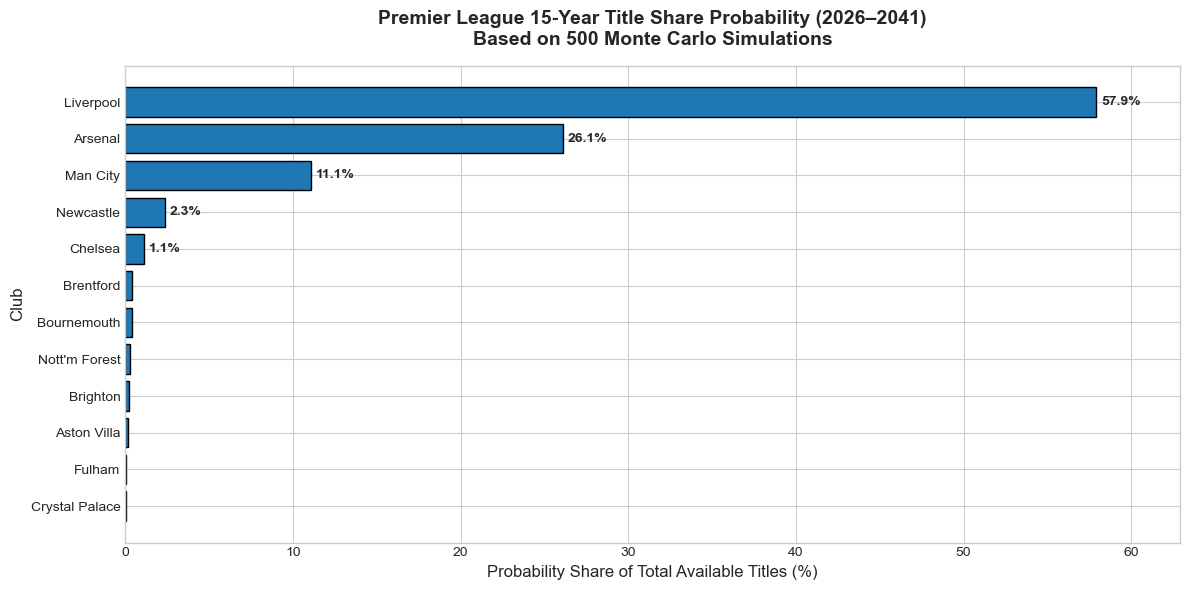

In [14]:
# Cell 14: Visualisation - 15-Year Premier League Title Probabilities

total_titles_awarded = NUM_SIMULATIONS * 15

df_summary = pd.DataFrame([
    {
        'Club': team,
        'Total Titles Won': title_counts_overall[team],
        'Title Share (%)': (title_counts_overall[team] / total_titles_awarded) * 100,
        'Expected Titles (out of 15)': (title_counts_overall[team] / NUM_SIMULATIONS),
        'Top 4 App Probability (%)': (top_4_counts[team] / total_titles_awarded) * 100
    }
    for team in team_ratings.index
]).sort_values(by='Total Titles Won', ascending=False)

display(df_summary.head(10))

# Plot bar chart of expected titles
plt.figure(figsize=(12, 6))
top_contenders = df_summary[df_summary['Total Titles Won'] > 0].sort_values(by='Total Titles Won', ascending=True)

bars = plt.barh(top_contenders['Club'], top_contenders['Title Share (%)'], color='#1f77b4', edgecolor='black')
plt.title(f'Premier League 15-Year Title Share Probability (2026–2041)\nBased on {NUM_SIMULATIONS} Monte Carlo Simulations', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Probability Share of Total Available Titles (%)', fontsize=12)
plt.ylabel('Club', fontsize=12)

# Add text labels on bars
for bar in bars:
    w = bar.get_width()
    if w > 0.5:
        plt.text(w + 0.3, bar.get_y() + bar.get_height()/2, f'{w:.1f}%', va='center', fontsize=10, fontweight='bold')

plt.xlim(0, max(top_contenders['Title Share (%)']) + 5)
plt.tight_layout()
plt.show()

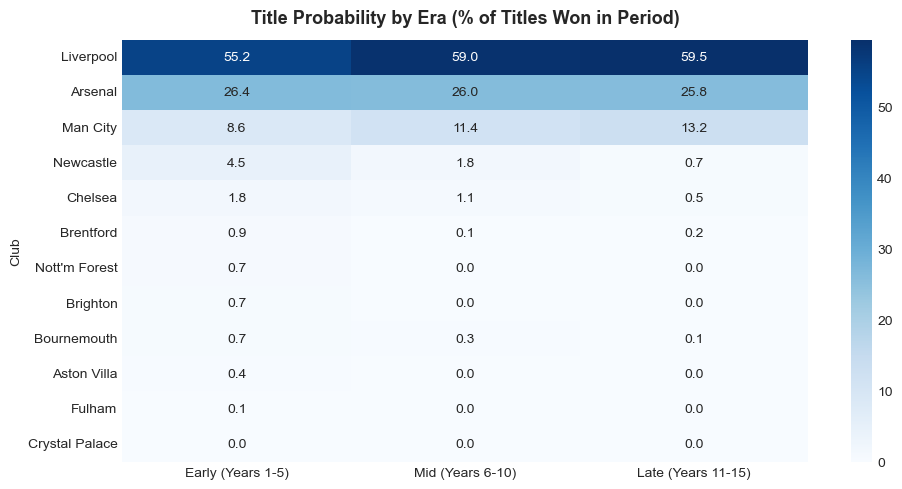

In [15]:
# Cell 15: Era Breakdown (Early, Mid, and Late Horizon)
eras = {
    'Early (Years 1-5)': list(df_sim['season'][:5]),
    'Mid (Years 6-10)': list(df_sim['season'][5:10]),
    'Late (Years 11-15)': list(df_sim['season'][10:15])
}

era_records = []
for club in top_contenders['Club']:
    row = {'Club': club}
    for era_name, seasons in eras.items():
        count = sum(titles_by_year[club][s] for s in seasons)
        row[era_name] = (count / (NUM_SIMULATIONS * 5)) * 100
    era_records.append(row)

df_eras = pd.DataFrame(era_records).set_index('Club')

# Plot stacked/grouped heatmap of eras
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.heatmap(df_eras.sort_values(by='Early (Years 1-5)', ascending=False), annot=True, fmt=".1f", cmap="Blues", cbar=True)
plt.title("Title Probability by Era (% of Titles Won in Period)", fontsize=13, fontweight='bold', pad=12)
plt.ylabel("Club")
plt.tight_layout()
plt.show()